State Schema 


In [5]:
from typing import TypedDict , Literal
from langgraph.graph import StateGraph , START , END
import random
class State(TypedDict):
    name : str
    mood : Literal['sad' , 'happy']

In [4]:
def node1(state:State):
    return {"name" : state['name'] }

def node2(state:State):
    return {"mood" : "happy"}

def node3(state:State):
    return {"mood" : "sad"}


def desision_node(state:State) -> Literal['node2' , 'node3']:

    if random.randint(1,2) == 1 :
        return 'node2'
    return 'node3'






Create a Agent workflow

In [6]:
builder = StateGraph(State)
builder.add_node("node1" , node1)
builder.add_node("node2" , node2)
builder.add_node("node3" , node3)

builder.add_edge(START , "node1")
builder.add_conditional_edges("node1" , desision_node)
builder.add_edge("node2" , END)
builder.add_edge("node3" , END)

In [7]:
graph = builder.compile()

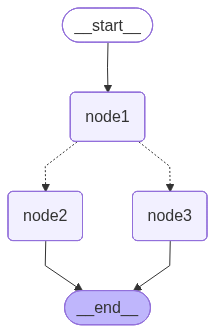

In [8]:
graph

In [18]:
graph.invoke(State(name="puvith" , mood="bad"))


{'name': 'puvith', 'mood': 'sad'}

In the above example even if we give Mood as bad which is not a valid literal it will not give an error which must not be the case hence we use validator 